# Build Dataset
This notebook constructs a slice-wise dataset from a raw tomogram (`.mrc`) and a corresponding label volume, then packages annotations, masks, and bounding boxes into a pickle consumed by `data.MrcDataset`.

## Purpose
- Convert label volumes into compact slice annotations and sparse masks that is easy to load and visualize.
- Derive bounding boxes per instance for training and evaluation

## Dataset Dictionary Structure (pickle file)

The dataset pickle file is a Python dictionary that describes a 3D tomogram dataset as slice-wise annotations, masks, and metadata. It is consumed by `data.MrcDataset` to build training/evaluation samples.

- mapclass: a mapping from class name to integer id, e.g. `{"hsp60": 0, "mitochondria": 1}`.
- annotations: nested dict → `class_name -> slice_index -> list[int]` of label ids present in that slice.
- masks: nested dict → `class_name -> slice_index -> scipy.sparse.csr_matrix` of shape `[H, W]`, holding integer labels (0 = background). Stored as CSR to save memory.
- bboxes: nested dict → `class_name -> slice_index -> label_id -> [x_min, y_min, width, height]` in pixels, computed from the mask on that slice.
- mrc_path: string path to the source `.mrc` volume.


In [8]:
import sys 
from tqdm import tqdm
sys.path.append("../src")
from tqdm import tqdm
import matplotlib.pyplot as plt
import utils
import pickle
import importlib 
importlib.reload(utils)
import numpy as np
import data
from scipy.sparse import csr_matrix

## Usage Preview
We first load a pre-built dataset pickle with `MrcDataset` and draw annotations for a sample slice to ensure rendering and color mapping work as expected.

reading dataset: /data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092031_mito.pkl
dataset map classes:  {'hsp60': 0, 'mitochondria': 1}
dataset length: 38
masks


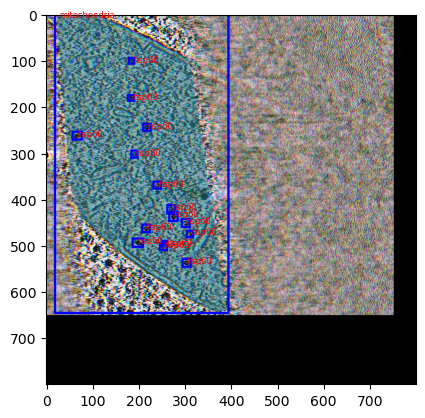

In [9]:
# a typical usage example
ds = data.MrcDataset("/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092031_mito.pkl", transform=data.getDefaultTransform(), add_classname=True, require_mask=True, mask_length=1)
d = ds[20]
utils.drawannotation(d["pixel_values"], d["labels"],font_size=6)

## Tomogram Inputs
We specify two inputs:
- Raw tomogram (`mrc_path`): the grayscale volume to visualize and reference.
- Label volume (`ribosome_path`): integer-labeled instances used to derive masks and bounding boxes.

In [20]:
mrc_path = "/data/transformer_project/transforemer_model/test_data/dxd20240920/tomo2/24092002_9.62Apx.mrc" 
ribosome_path = "/data/transformer_project/transforemer_model/test_data/dxd20240920/ribo/24092002.mrc"

## Inspect Volume Slices
We preview a representative slice (e.g., index 200) from the raw tomogram and the label volume to confirm alignment and label presence.

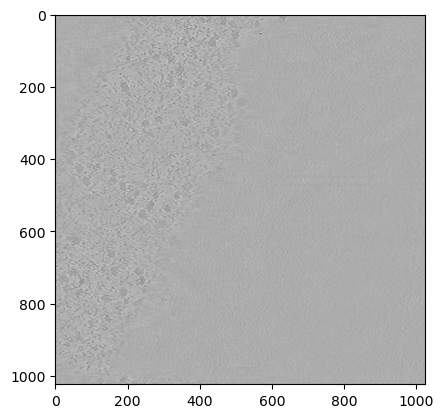

In [21]:
mrc_original = utils.readTomogram(mrc_path)
plt.imshow(mrc_original[200], cmap="gray")

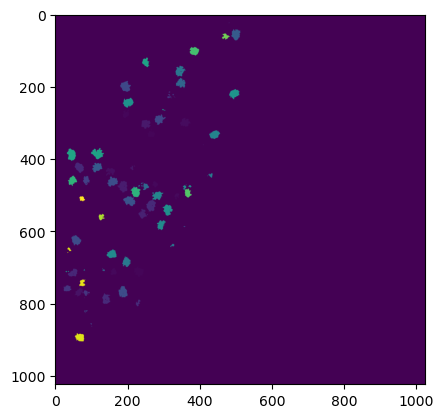

In [22]:
mrc_label = utils.readTomogram(ribosome_path)
plt.imshow(mrc_label[200])

## Construct Slice-wise Dataset
This step converts the integer-labeled ribosome volume into a compact, slice-wise dataset used by `data.MrcDataset`. For each slice:
- Collect `labels > 0` as instance IDs present on the slice and store them in `annotations["ribosome"][i]`. Label `0` is treated as background and ignored.
- Store the full 2D label map as a sparse matrix (`csr_matrix`) in `masks["ribosome"][i]` to save memory.
- For every instance `j` on the slice, compute a bounding box `[x_min, y_min, width, height]` from the pixel coordinates where `mrc_label[i] == j`, and write it to `bboxes["ribosome"][i][j]`.
- Assemble the dataset dictionary `ann` with:
  - `annotations`, `masks`, `bboxes`
  - `mapclass = {"ribosome": 0}` (adjust as needed for multiple classes)
  - `mrc_shape` (full volume shape) and `mrc_path` (path to the raw tomogram).
- Finally, serialize the dictionary to `../datasets/temp.pkl` for downstream loading and visualization.

Notes:
- Ensure the label volume is spatially aligned with the raw tomogram.
- Adjust the slice range (`range(500)`) to cover the actual depth of your volume.
- Instance labels must be positive integers per slice; background is `0`.
- CSR storage reduces memory footprint while preserving exact integer labels.

In [23]:
annotations = {"ribosome": {}} 
masks = {"ribosome": {}} 
bboxes = {"ribosome": {}} 
for i in tqdm(range(500)):
    labels = np.unique(mrc_label[i])
    labels = labels[labels > 0]
    if len(labels) > 0:
        annotations["ribosome"][i] = labels.tolist()
        masks["ribosome"][i] = csr_matrix(mrc_label[i])
        bboxes["ribosome"][i] = {}
        for j in labels:
            x, y = np.where(mrc_label[i] == j)
            bboxes["ribosome"][i][j] = [np.min(y), np.min(x), np.max(y) - np.min(y) + 1, np.max(x) - np.min(x) + 1]
            
ann = {
        "annotations": annotations,
        "masks": masks,
        "bboxes": bboxes,
        "mapclass": {"ribosome": 0},
        # "mrc": mix_labels[name],
        "mrc_shape": mrc_label.shape,
        "mrc_path": mrc_path,
    }
with open(f"../datasets/temp.pkl", 'wb') as f:
    pickle.dump(ann, f)

100%|██████████| 500/500 [00:54<00:00,  9.17it/s]


masks


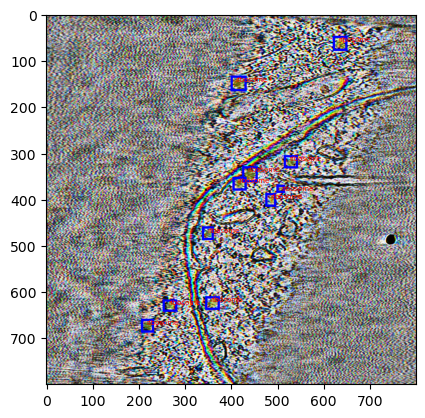

In [25]:
ds = data.MrcDataset("../datasets/temp.pkl", transform=data.getConstantTransform(), add_classname=True, require_mask=True, mask_length=1)
d = ds[50]
utils.drawannotation(d["pixel_values"], d["labels"],font_size=5)